# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


## 1. Introdução Teórica

Em aplicações modernas de Processamento Digital de Sinais (PDS), a arquitetura de transceptores digitais baseia-se na transformação eficiente da informação para o tráfego em canais de comunicação. O sistema realiza essa interface fundamentalmente por meio de duas operações de filtragem essenciais na camada física: a formatação de pulso na transmissão e a filtragem casada na recepção.

* **Formatação de Pulso (Transmissão)**

A geração do sinal modulado em banda base consiste em mapear a fonte de bits em símbolos complexos $s_k$ — representados por suas componentes nos eixos em fase $i_k$ e quadratura $q_k$ — e interpolá-los utilizando um filtro formatador de pulso $p(t)$. Matematicamente, o sinal transmitido $s(t)$ no domínio do tempo é expresso como:

$$
 s(t) = \sum_{k=-\infty}^{\infty} s_k p(t - kT_s)
$$ 


Para limitar a banda espectral do sinal, o pulso $p(t)$ comumente assume geometrias específicas, como retangular, cosseno levantado ou gaussiano.

* **Filtragem Casada (Recepção)**

No receptor, o sinal encontra-se degradado pelas características do canal[cite: 954]. Para otimizar a detecção, a amostragem deve ser precedida por um filtro linear (*matched filter*) cuja resposta ao impulso $h(t)$ é projetada para corresponder ao pulso transmitido $g(t)$. O filtro casado é modelado como a versão invertida no tempo e atrasada do pulso original:

$$
 h(t) = g(T_s - t)
$$ 

Essa operação atua correlacionando o sinal recebido com o formato de onda esperado, maximizando a Relação Sinal-Ruído (SNR) no instante exato da amostragem $t = kT_s$ e atingindo o limite teórico máximo na saída do filtro de:

$$
SNR = \frac{2\mathbb{E}[|s_k|^2]E_p}{N_0}
$$ 

## 2. Objetivos do Projeto

Esta atividade prática visa a implementação e análise de sistemas de comunicação digital utilizando a biblioteca de simulação [OptiCommPy](https://github.com/edsonportosilva/OptiCommPy). Os principais objetivos deste projeto são:

* **Modelagem de Transceptor Banda Base:** Desenvolver um modelo funcional de um transmissor (desde a geração de sequências binárias até a saída do DAC) e de um receptor digital (abrangendo ADC, filtragem casada, reamostragem, detecção de símbolos e contagem de erros) para esquemas de modulação $M$-PAM.
* **Avaliação de Desempenho em Canais AWGN:** Analisar o comportamento das modulações sob a influência de ruído gaussiano branco aditivo, através do levantamento de curvas de Taxa de Erro de Bit (BER) em função da Relação Sinal-Ruído (SNR).
* **Análise de Restrição de Banda:** Investigar os efeitos deletérios e o impacto no desempenho global do sistema quando os sinais são submetidos a um canal de comunicações com largura de banda limitada.





In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.metrics import bert, fastBERcalc
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate
from optic.utils import parameters, dBm2W
from optic.models.devices import dac, adc
from optic.models.channels import awgn
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal

### Parameters Simulation

In [21]:
# Rate Sybol
Rs= 10e8

#Sample Per Symbol
SpS= 32

# Sample Rate
Fa= Rs*SpS

#Sample Time
Ta= 1/Fa

#Modulation Order
M= [2,4,16]

#Parameters for Bits Generation
paramBits =  parameters()
paramBits.nBits = 100000
paramBits.mode = 'random'
paramBits.seed = 10

#Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'nrz'
paramPulse.SpS = SpS

bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)

#Mapping = [modulateGray(bits, m, 'pam') for m in M]

t = np.arange(0, pulse.size) * Ta

#Parameters for DAC

j=8 #Um fator de oversampling para garantir que o DAC opere bem acima da taxa de Nyquist do sinal e ajudar no plot
paramDAC = parameters()
paramDAC.inFs = Fa
paramDAC.outFs =  j*Fa
paramDAC.nBits = 12
paramDAC.ENOB = 12
paramDAC.Vpp = 2
paramDAC.AIF= False





## PulseShape for filtering 

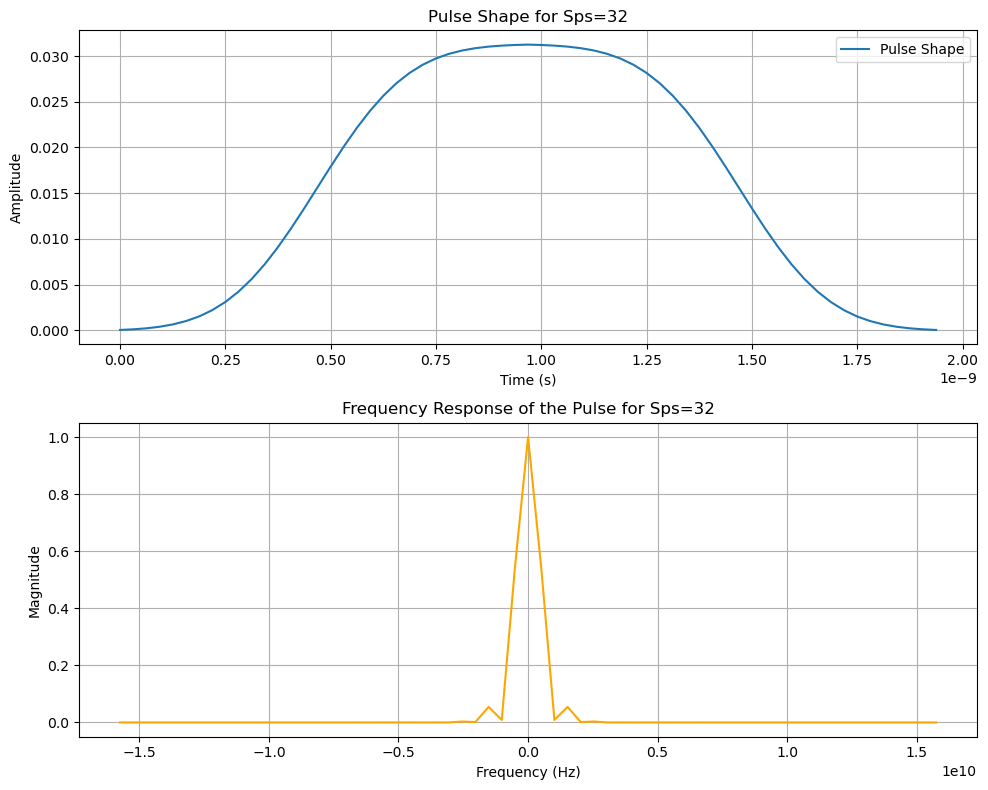

In [24]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    
# Pulse Shape
axs[0].plot(t, pulse, label='Pulse Shape')
axs[0].set_xlabel('Time (s)')          # Note que em subplots usamos set_xlabel
axs[0].set_ylabel('Amplitude')
axs[0].set_title(f'Pulse Shape for Sps={SpS}')
axs[0].grid(True)
axs[0].legend()

# Ftt of the pulse
P = np.fft.fftshift(np.fft.fft(pulse))
freqs = np.fft.fftshift(np.fft.fftfreq(P.size, d=Ta))
    
# Frequency Reponse
axs[1].plot(freqs, np.abs(P), color='orange')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].set_title(f'Frequency Response of the Pulse for Sps={SpS}')
axs[1].grid(True)
    
plt.tight_layout()    
plt.show()
  

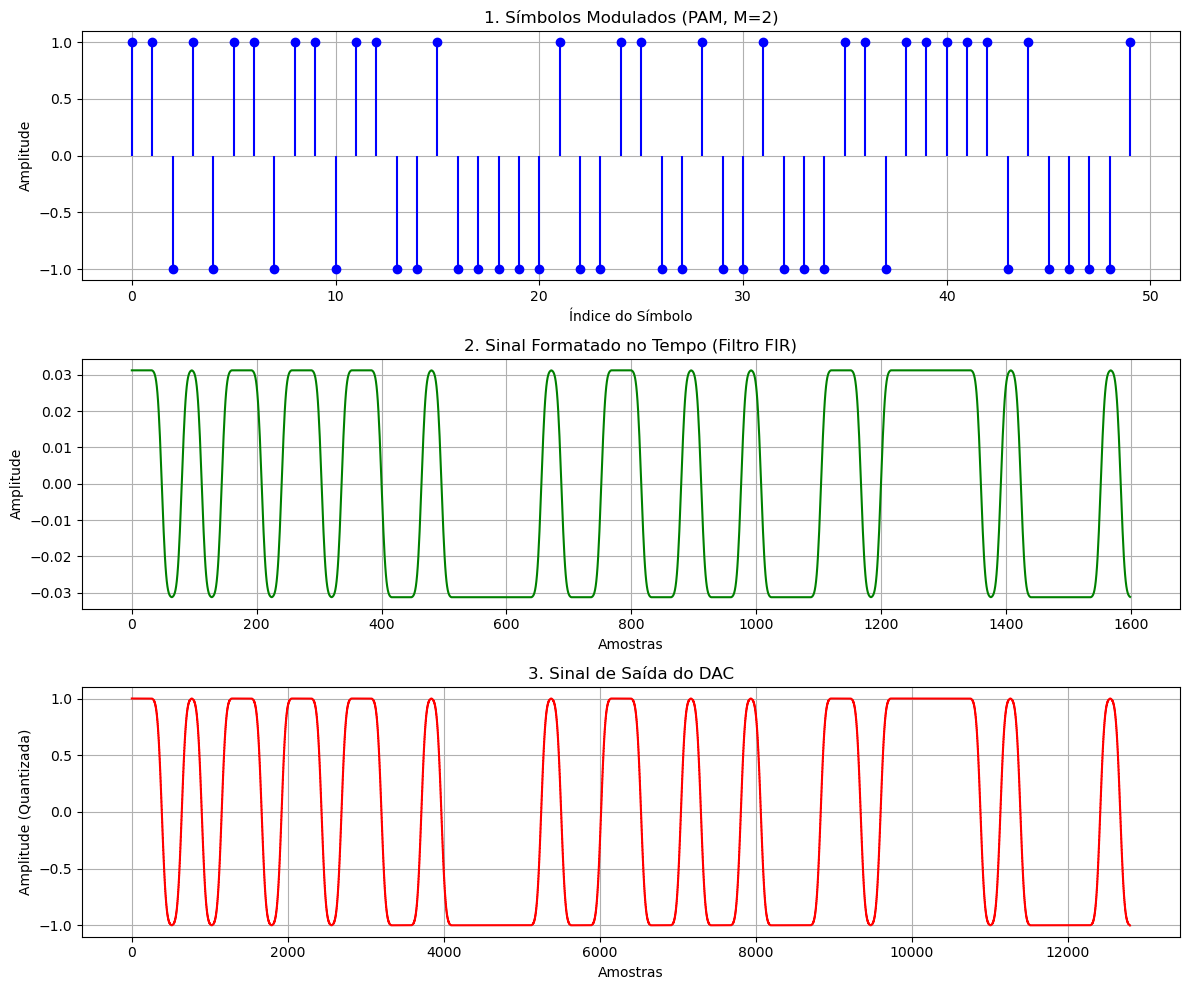

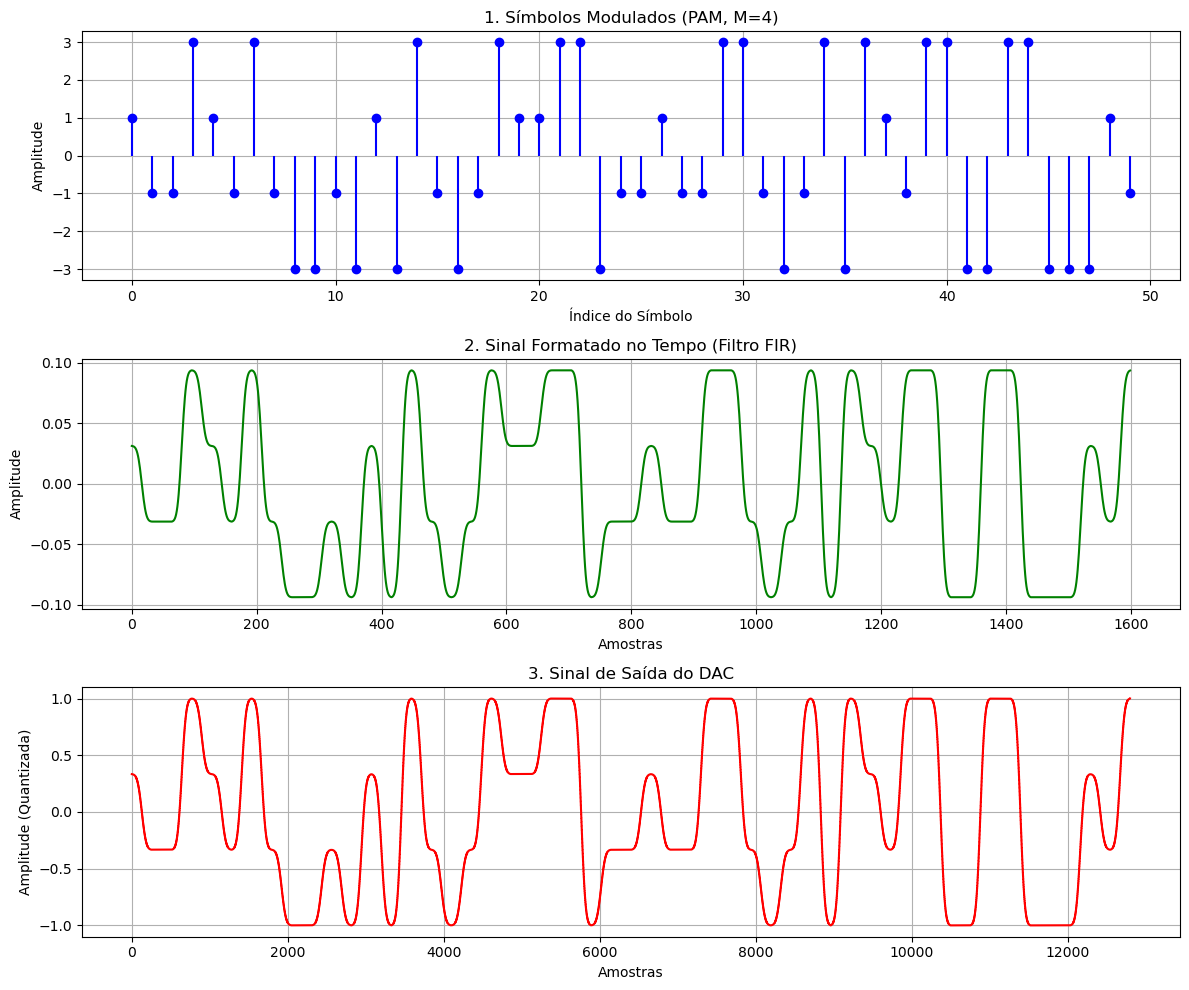

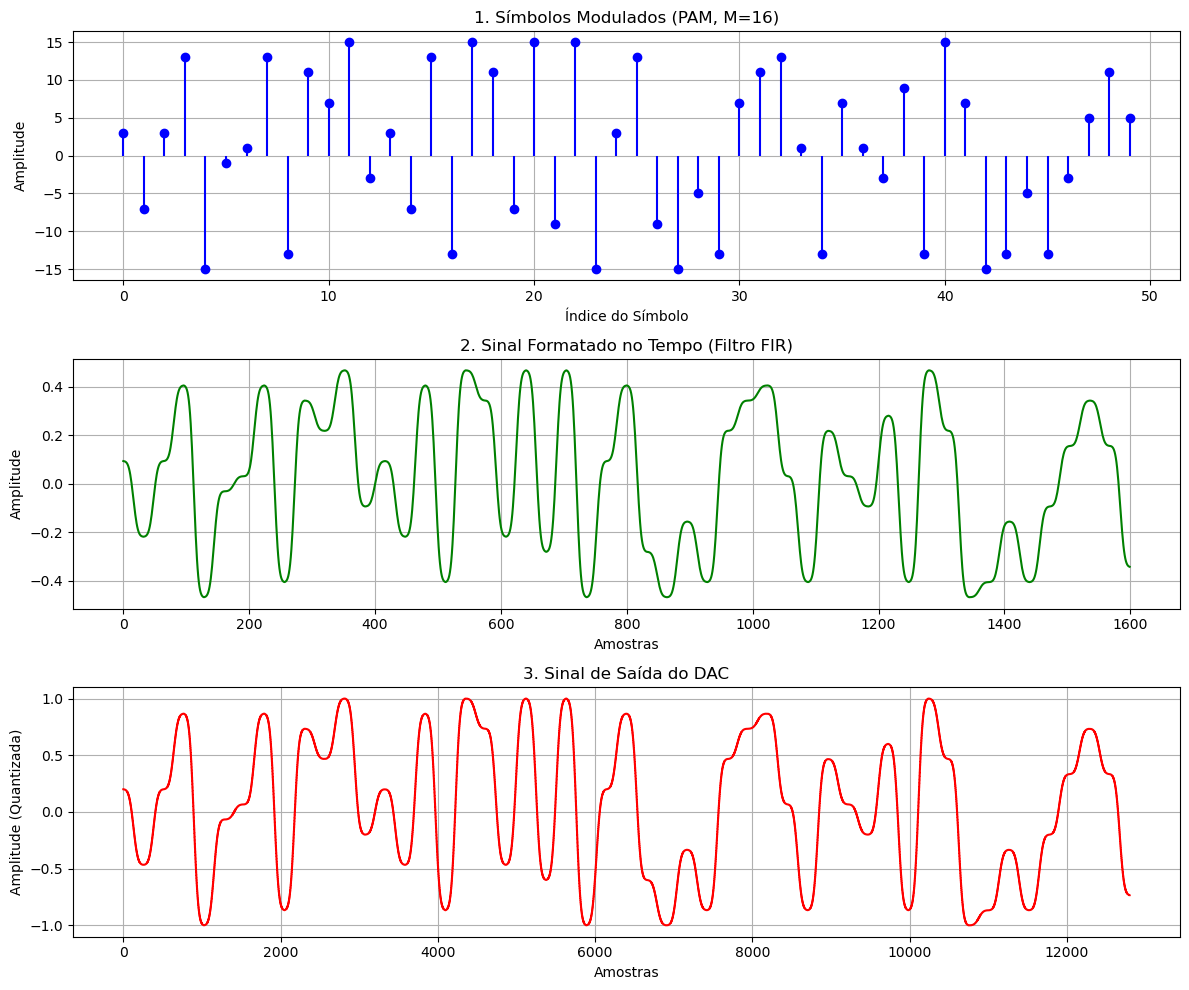

In [25]:
TxSymbols_list = [] 
TxSigDac_list = []

for i in range(len(M)):
    # Mapping 'pam' -> Upsample -> Pulse Shaping -> DAC ->
    TxSymbols = modulateGray(bits, M[i], 'pam')
    TxSymbolsUp = upsample(TxSymbols, SpS)
    TxSymbols_Pulsed = firFilter(pulse, TxSymbolsUp)
    TxSigDac = dac(TxSymbols_Pulsed, paramDAC)
    
    #Saving the results in lists 
    TxSymbols_list.append(TxSymbols)
    TxSigDac_list.append(TxSigDac)

   
    fig, axs = plt.subplots(3, 1, figsize=(12, 10))
    
    # Limit the number of symbols and samples to plot for better visualization
    num_symbols_to_plot = 50
    num_samples_to_plot = num_symbols_to_plot * SpS 
    
    # Symbols after modulation (PAM)
    axs[0].stem(TxSymbols[:num_symbols_to_plot], basefmt=" ", linefmt='b-', markerfmt='bo')
    axs[0].set_title(f'1. Símbolos Modulados (PAM, M={M[i]})')
    axs[0].set_xlabel('Índice do Símbolo')
    axs[0].set_ylabel('Amplitude')
    axs[0].grid(True)

    # Signal after transmission through the FIR filter (Pulse Shaping)
    axs[1].plot(TxSymbols_Pulsed[:num_samples_to_plot], color='green')
    axs[1].set_title(f'2. Sinal Formatado no Tempo (Filtro FIR)')
    axs[1].set_xlabel('Amostras')
    axs[1].set_ylabel('Amplitude')
    axs[1].grid(True)

    # Signal at the output of the DAC (Quantized and held)
    # Usamos drawstyle='steps-post' para dar aquele aspecto de "escadinha" 
    # típico do processo de quantização e retenção (zero-order hold) de um DAC
    axs[2].plot(TxSigDac[:j*num_samples_to_plot], color='red', drawstyle='steps-post')
    axs[2].set_title(f'3. Sinal de Saída do DAC')
    axs[2].set_xlabel('Amostras')
    axs[2].set_ylabel('Amplitude (Quantizada)')
    axs[2].grid(True)

    # Ajusta os espaçamentos e exibe a figura da iteração atual
    plt.tight_layout()
    plt.show()

### Constelação dos Simbolos gerados para M-modulation

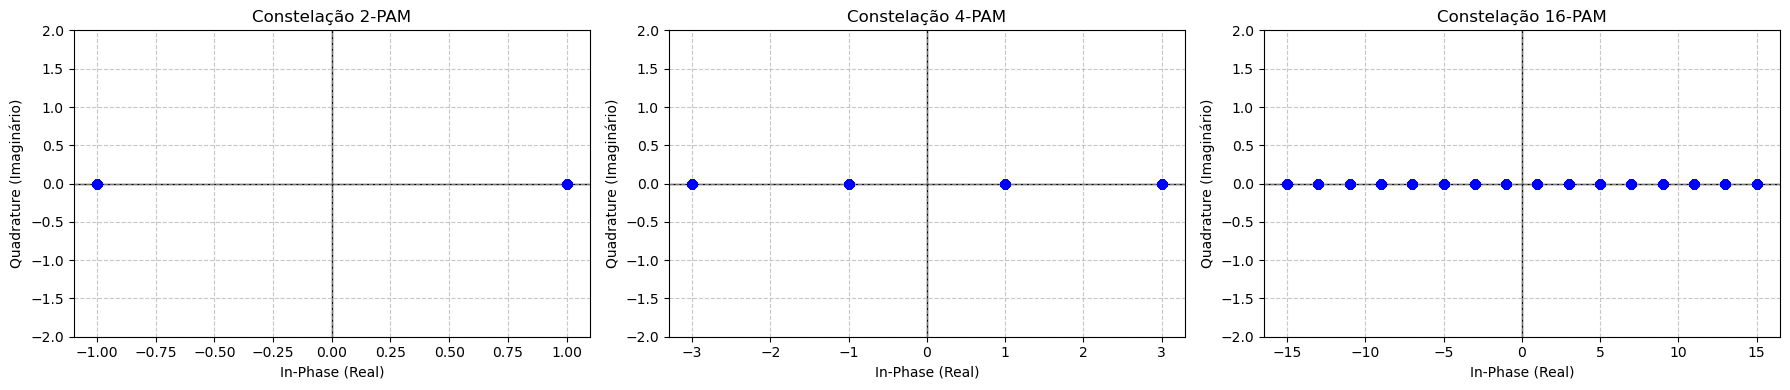

In [26]:
fig, axs = plt.subplots(1, len(M), figsize=(18, 4))

# If M has only one element, axs will not be a list, so we convert it to a list to avoid breaking the 'for' loop
if len(M) == 1:
    axs = [axs]

for i in range(len(M)):
    # Symbols [i] of this M saved in the list before
    symbols = TxSymbols_list[i]
    
    # Ik and Qk
    # In PAM modulation Ik = 0, always.
    axe_i = np.real(symbols)
    axe_q = np.imag(symbols)
    
    # plot
    axs[i].scatter(axe_i, axe_q, color='blue', alpha=0.5, zorder=3)
    
    axs[i].set_title(f'Constelação {M[i]}-PAM')
    axs[i].set_xlabel('In-Phase (Real)')
    axs[i].set_ylabel('Quadrature (Imaginário)')
    
    axs[i].axhline(0, color='black', linewidth=1, zorder=1)
    axs[i].axvline(0, color='black', linewidth=1, zorder=1)
    
    # 
    axs[i].grid(True, linestyle='--', alpha=0.7, zorder=0)
    
    axs[i].set_ylim(-2, 2)

plt.tight_layout()
plt.show()

### AWGN Channel 